In [1]:
import pandas as pd
import numpy as np

def _load_returns(path, skiprows=None):
    df = pd.read_csv(path, index_col=0, header=0, skiprows=skiprows)
    df = df.apply(lambda col: col.map(lambda x: float(str(x).strip('%')) / 100))
    df.columns = df.columns.str.strip()
    n = len(df)
    df.index = pd.date_range(start='2004-01-31', periods=n, freq='ME')
    df.index.name = 'Date'
    return df

df_assets  = _load_returns('Asset_Time_Series.csv')
df_indices = _load_returns('Index_Time_Series.csv', skiprows=[1])

# Align on common dates (inner join)
idx   = df_assets.index.intersection(df_indices.index)
r_all = df_assets.loc[idx]
F_all = df_indices.loc[idx]
dates  = r_all.index
assets = r_all.columns.tolist()

print('Assets shape :', r_all.shape)
print('Indices shape:', F_all.shape)
print('Date range   :', dates[0].strftime('%b %Y'), '→', dates[-1].strftime('%b %Y'))
print('All factors  :', F_all.columns.tolist())

Assets shape : (120, 5)
Indices shape: (120, 27)
Date range   : Jan 2004 → Dec 2013
All factors  : ['US Muni', 'US Tbill 1-3yr', 'US AGG', 'Global AGG', 'US Dollar', 'Commodities', 'Long Short HF', 'Event Driven HF', 'HF FOF Div', 'Relative Value HF', 'EM Bond', 'TIPs', 'High Yield', 'MSCI World', 'MSCI Canada', 'MSCI EAFE', 'MSCI EM Equity', 'MSCI Europe', 'MSCI Japan', 'MSCI Asia ex-J', 'US Growth', 'US Value', 'US Small Cap', 'US Mid Cap', 'Gold', 'S&P500', 'Cash']


---
# Step 1 — Asset Identification

Compute the Pearson correlation between each asset and every one of the 27 index factors.  
The factor with the **highest absolute correlation** is interpreted as the asset's *home class* (e.g. Asset 1 → US AGG → investment-grade bonds).

=== Top 5 Factors by |Correlation| per Asset ===

Asset 1:
  US AGG                     r = +0.892  |r| = 0.892
  TIPs                       r = +0.727  |r| = 0.727
  US Tbill 1-3yr             r = +0.678  |r| = 0.678
  Global AGG                 r = +0.597  |r| = 0.597
  US Muni                    r = +0.545  |r| = 0.545

Asset 2:
  US Growth                  r = +0.936  |r| = 0.936
  S&P500                     r = +0.885  |r| = 0.885
  US Mid Cap                 r = +0.879  |r| = 0.879
  US Small Cap               r = +0.854  |r| = 0.854
  MSCI World                 r = +0.852  |r| = 0.852

Asset3:
  Commodities                r = +0.708  |r| = 0.708
  MSCI Canada                r = +0.668  |r| = 0.668
  Long Short HF              r = +0.656  |r| = 0.656
  Event Driven HF            r = +0.648  |r| = 0.648
  MSCI EM Equity             r = +0.635  |r| = 0.635

Asset 4:
  HF FOF Div                 r = +0.583  |r| = 0.583
  Commodities                r = +0.528  |r| = 0.528
  MSCI Cana

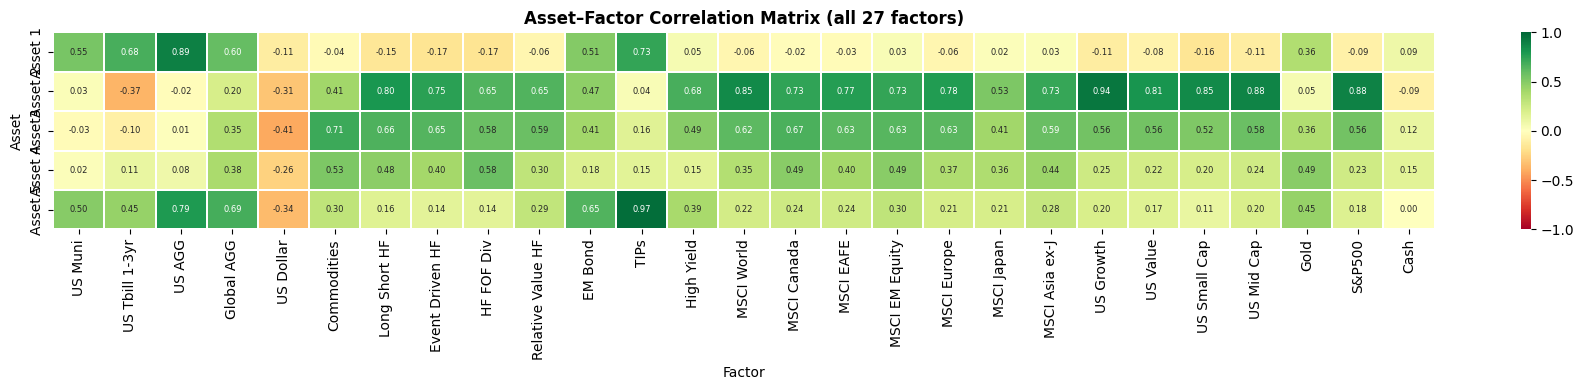

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation: assets (rows) × all 27 factors (columns)
corr_df = pd.DataFrame(
    {asset: F_all.corrwith(r_all[asset]) for asset in assets}
).T

# Print top-5 factors per asset
print('=== Top 5 Factors by |Correlation| per Asset ===\n')
for asset in assets:
    top5 = corr_df.loc[asset].abs().sort_values(ascending=False).head(5)
    print(f'{asset}:')
    for fac, absval in top5.items():
        sign = corr_df.loc[asset, fac]
        print(f'  {fac:25s}  r = {sign:+.3f}  |r| = {absval:.3f}')
    print()

# Heatmap
fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    corr_df, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    vmin=-1, vmax=1, ax=ax, linewidths=0.3, annot_kws={'size': 6}
)
ax.set_title('Asset–Factor Correlation Matrix (all 27 factors)', fontsize=12, fontweight='bold')
ax.set_xlabel('Factor'); ax.set_ylabel('Asset')
plt.tight_layout()
plt.savefig('asset_factor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Step 2 — Per-Asset Factor Selection (5 factors each)

For each asset we pick **exactly 5 factors**:

| Slot | Rule |
|------|------|
| 1 | **Home factor** — highest `|r|` overall (identifies the asset class) |
| 2–5 | **Best from each of the 4 remaining risk buckets** (by `|r|`) |

**Risk buckets:** Equity · Rates · Credit · Alternatives · Macro  
One bucket is "used" by the home factor; we fill one slot from each of the remaining four.  
This ensures coverage across all major return drivers, which is exactly what you need to pick up regime switches.

In [3]:
BUCKETS = {
    'Equity':       ['S&P500', 'MSCI World', 'MSCI EM Equity', 'MSCI Europe',
                     'MSCI Japan', 'MSCI Asia ex-J', 'US Growth', 'US Value',
                     'US Small Cap', 'US Mid Cap'],
    'Rates':        ['US AGG', 'Global AGG', 'US Muni', 'US Tbill 1-3yr'],
    'Credit':       ['High Yield'],
    'Alternatives': ['Long Short HF', 'Event Driven HF', 'HF FOF Div', 'Relative Value HF'],
    'Macro':        ['US Dollar', 'Commodities', 'Gold', 'Cash'],
}

BUCKET_ORDER = ['Equity', 'Rates', 'Credit', 'Alternatives', 'Macro']

def factor_bucket(fname):
    for bname, members in BUCKETS.items():
        if fname in members:
            return bname
    return 'Other'

def select_five_factors(asset, corr_series):
    """
    1. Home  = top |r| overall.
    2. Fill  = best (by |r|) from each remaining bucket.
    3. Fallback if a bucket is empty: take next-best overall.
    """
    ranked = corr_series.abs().sort_values(ascending=False)

    home        = ranked.index[0]
    home_bucket = factor_bucket(home)
    selected    = [home]
    used_bkts   = {home_bucket}

    for bname in BUCKET_ORDER:
        if bname == home_bucket:
            continue
        candidates = [f for f in ranked.index
                      if factor_bucket(f) == bname and f not in selected]
        if candidates:
            selected.append(candidates[0])
        if len(selected) == 5:
            break

    # Fallback: fill to 5 from top-ranked not yet chosen
    for f in ranked.index:
        if len(selected) >= 5:
            break
        if f not in selected:
            selected.append(f)

    return selected[:5]


ASSET_FACTORS = {}
rows = []
print('=== Per-Asset Factor Selection (5 factors each) ===\n')
for asset in assets:
    factors = select_five_factors(asset, corr_df.loc[asset])
    ASSET_FACTORS[asset] = factors
    print(f'{asset}:')
    for f in factors:
        corr_val = corr_df.loc[asset, f]
        label    = '← HOME' if f == factors[0] else ''
        print(f'  [{factor_bucket(f):12s}]  {f:25s}  r = {corr_val:+.3f}  {label}')
        rows.append({'Asset': asset, 'Bucket': factor_bucket(f), 'Factor': f,
                     'Correlation': round(corr_val, 3), 'Role': 'Home' if label else 'Cross-risk'})
    print()

display(pd.DataFrame(rows).set_index(['Asset', 'Bucket', 'Factor']))

=== Per-Asset Factor Selection (5 factors each) ===

Asset 1:
  [Rates       ]  US AGG                     r = +0.892  ← HOME
  [Equity      ]  US Small Cap               r = -0.160  
  [Credit      ]  High Yield                 r = +0.049  
  [Alternatives]  HF FOF Div                 r = -0.169  
  [Macro       ]  Gold                       r = +0.359  

Asset 2:
  [Equity      ]  US Growth                  r = +0.936  ← HOME
  [Rates       ]  US Tbill 1-3yr             r = -0.370  
  [Credit      ]  High Yield                 r = +0.678  
  [Alternatives]  Long Short HF              r = +0.804  
  [Macro       ]  Commodities                r = +0.406  

Asset3:
  [Macro       ]  Commodities                r = +0.708  ← HOME
  [Equity      ]  MSCI EM Equity             r = +0.635  
  [Rates       ]  Global AGG                 r = +0.352  
  [Credit      ]  High Yield                 r = +0.493  
  [Alternatives]  Long Short HF              r = +0.656  

Asset 4:
  [Alternatives]  HF 

Correlation        Role
Asset   Bucket       Factor                                    
Asset 1 Rates        US AGG                   0.892        Home
        Equity       US Small Cap            -0.160  Cross-risk
        Credit       High Yield               0.049  Cross-risk
        Alternatives HF FOF Div              -0.169  Cross-risk
        Macro        Gold                     0.359  Cross-risk
Asset 2 Equity       US Growth                0.936        Home
        Rates        US Tbill 1-3yr          -0.370  Cross-risk
        Credit       High Yield               0.678  Cross-risk
        Alternatives Long Short HF            0.804  Cross-risk
        Macro        Commodities              0.406  Cross-risk
Asset3  Macro        Commodities              0.708        Home
        Equity       MSCI EM Equity           0.635  Cross-risk
        Rates        Global AGG               0.352  Cross-risk
        Credit       High Yield               0.493  Cross-risk
        Alternatives Long Short HF            0.656  Cross-risk
Asset 4 Alternatives HF FOF Div               0.583        Home
        Equity       MSCI EM Equity           0.487  Cross-risk
        Rates        Global AGG               0.378  Cross-risk
        Credit       High Yield               0.149  Cross-risk
        Macro        Commodities              0.528  Cross-risk
Asset 5 Other        TIPs                     0.973        Home
        Equity       MSCI EM Equity           0.300  Cross-risk
        Rates        US AGG                   0.787  Cross-risk
        Credit       High Yield               0.387  Cross-risk
        Alternatives Relative Value HF        0.291  Cross-risk

---
# Kalman Filter Model

Identical to v1. One `KalmanFactorModel` per asset; each asset now has its own 5-column factor matrix.

In [4]:
from scipy.optimize import minimize

class KalmanFactorModel:
    """
    Time-varying factor model for a single asset.
    Observation: r_t = F_t' @ beta_t + eps_t,   eps_t ~ N(0, sigma2)
    State:       beta_t = beta_{t-1} + eta_t,   eta_t ~ N(0, q*I)
    """

    def __init__(self, r, F, sigma2_init=None, q_init=1e-4):
        self.r = np.asarray(r, dtype=float)
        self.F = np.asarray(F, dtype=float)
        self.T, self.K = self.F.shape

        if sigma2_init is None:
            beta_ols, *_ = np.linalg.lstsq(self.F, self.r, rcond=None)
            resid = self.r - self.F @ beta_ols
            sigma2_init = float(np.var(resid))

        self.sigma2 = sigma2_init
        self.q      = q_init

        self.beta_filtered = None
        self.P_filtered    = None
        self._innovations  = None
        self._innov_vars   = None
        self._beta_prior   = None
        self._P_prior      = None
        self.beta_smoothed = None
        self.P_smoothed    = None

    def filter(self, sigma2=None, q=None):
        sigma2 = self.sigma2 if sigma2 is None else sigma2
        q      = self.q      if q      is None else q

        T, K = self.T, self.K
        Q = q * np.eye(K)
        I = np.eye(K)

        beta, *_ = np.linalg.lstsq(self.F, self.r, rcond=None)
        P        = 10.0 * np.eye(K)

        beta_filtered = np.zeros((T, K))
        P_filtered    = np.zeros((T, K, K))
        beta_prior    = np.zeros((T, K))
        P_prior       = np.zeros((T, K, K))
        innovations   = np.zeros(T)
        innov_vars    = np.zeros(T)

        for t in range(T):
            f    = self.F[t]
            b_pr = beta.copy()
            P_pr = P + Q
            beta_prior[t] = b_pr
            P_prior[t]    = P_pr

            v = self.r[t] - f @ b_pr
            S = float(f @ P_pr @ f) + sigma2

            Kg   = P_pr @ f / S
            beta = b_pr + Kg * v
            P    = (I - np.outer(Kg, f)) @ P_pr

            beta_filtered[t] = beta
            P_filtered[t]    = P
            innovations[t]   = v
            innov_vars[t]    = S

        self.beta_filtered = beta_filtered
        self.P_filtered    = P_filtered
        self._beta_prior   = beta_prior
        self._P_prior      = P_prior
        self._innovations  = innovations
        self._innov_vars   = innov_vars
        return self

    def log_likelihood(self, sigma2=None, q=None):
        self.filter(sigma2, q)
        v = self._innovations
        S = self._innov_vars
        return float(-0.5 * np.sum(np.log(S) + v**2 / S))

    def fit(self):
        def objective(params):
            return -self.log_likelihood(np.exp(params[0]), np.exp(params[1]))

        x0     = [np.log(self.sigma2), np.log(self.q)]
        result = minimize(objective, x0, method='L-BFGS-B')

        self.sigma2      = float(np.exp(result.x[0]))
        self.q           = float(np.exp(result.x[1]))
        self._opt_result = result
        self.filter()
        return self

    def smooth(self):
        if self.beta_filtered is None:
            raise RuntimeError('Call filter() or fit() before smooth().')

        T, K = self.T, self.K
        beta_s = np.zeros((T, K))
        P_s    = np.zeros((T, K, K))

        beta_s[-1] = self.beta_filtered[-1]
        P_s[-1]    = self.P_filtered[-1]

        for t in range(T - 2, -1, -1):
            P_pr   = self._P_prior[t + 1]
            G      = self.P_filtered[t] @ np.linalg.inv(P_pr)
            beta_s[t] = self.beta_filtered[t] + G @ (beta_s[t + 1] - self._beta_prior[t + 1])
            P_s[t]    = self.P_filtered[t]    + G @ (P_s[t + 1] - P_pr) @ G.T

        self.beta_smoothed = beta_s
        self.P_smoothed    = P_s
        return self

---
# Fit Per-Asset Kalman Models

Each asset gets its own `F_mat` (5 tailored columns) and its own MLE-estimated `(sigma2, q)` pair.

In [5]:
models = {}
for asset in assets:
    factors = ASSET_FACTORS[asset]
    F_mat   = F_all[factors].values   # (T, 5)
    r_vec   = r_all[asset].values

    m = KalmanFactorModel(r_vec, F_mat)
    m.fit().smooth()
    models[asset] = m

    print(f"{asset}")
    print(f"  factors   : {factors}")
    print(f"  sigma2    : {m.sigma2:.6f}")
    print(f"  q         : {m.q:.2e}")
    print(f"  LL        : {m.log_likelihood():.1f}")
    print(f"  converged : {m._opt_result.success}")
    print()

Asset 1
  factors   : ['US AGG', 'US Small Cap', 'High Yield', 'HF FOF Div', 'Gold']
  sigma2    : 0.000009
  q         : 2.74e-05
  LL        : 602.0
  converged : True

Asset 2
  factors   : ['US Growth', 'US Tbill 1-3yr', 'High Yield', 'Long Short HF', 'Commodities']
  sigma2    : 0.000319
  q         : 3.30e-04
  LL        : 404.7
  converged : True

Asset3
  factors   : ['Commodities', 'MSCI EM Equity', 'Global AGG', 'High Yield', 'Long Short HF']
  sigma2    : 0.002316
  q         : 7.28e-11
  LL        : 292.4
  converged : True

Asset 4
  factors   : ['HF FOF Div', 'MSCI EM Equity', 'Global AGG', 'High Yield', 'Commodities']
  sigma2    : 0.000045
  q         : 8.66e-04
  LL        : 493.1
  converged : True

Asset 5
  factors   : ['TIPs', 'MSCI EM Equity', 'US AGG', 'High Yield', 'Relative Value HF']
  sigma2    : 0.000001
  q         : 8.96e-04
  LL        : 617.6
  converged : True



---
# Visualise Time-Varying Factor Loadings

Each subplot: smoothed beta path (solid) + 95 % confidence band (±2σ from diagonal of P_smoothed).  
Dashed line = static OLS beta for reference. GFC window shaded in red.

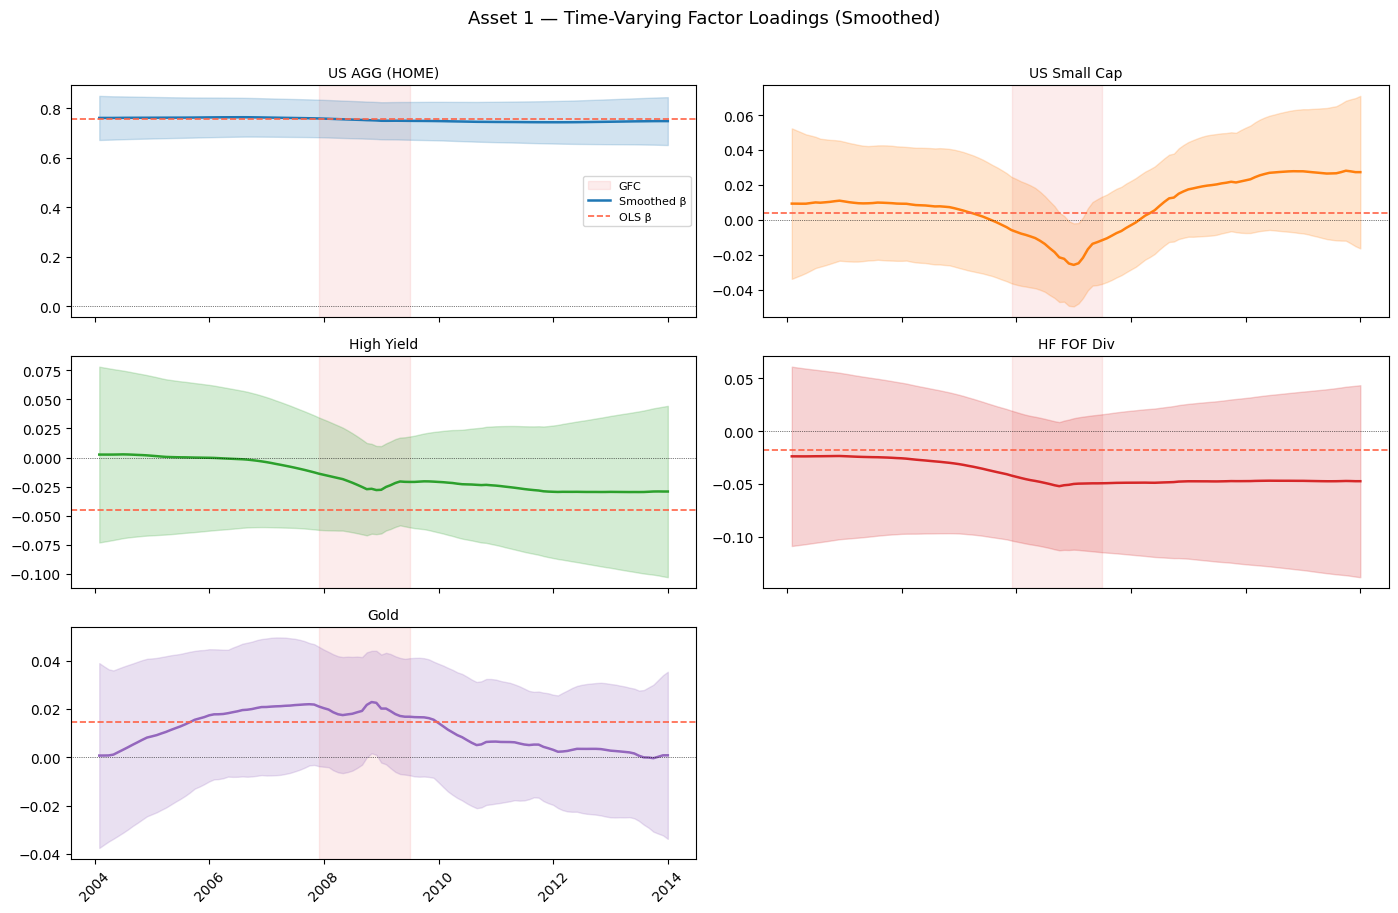

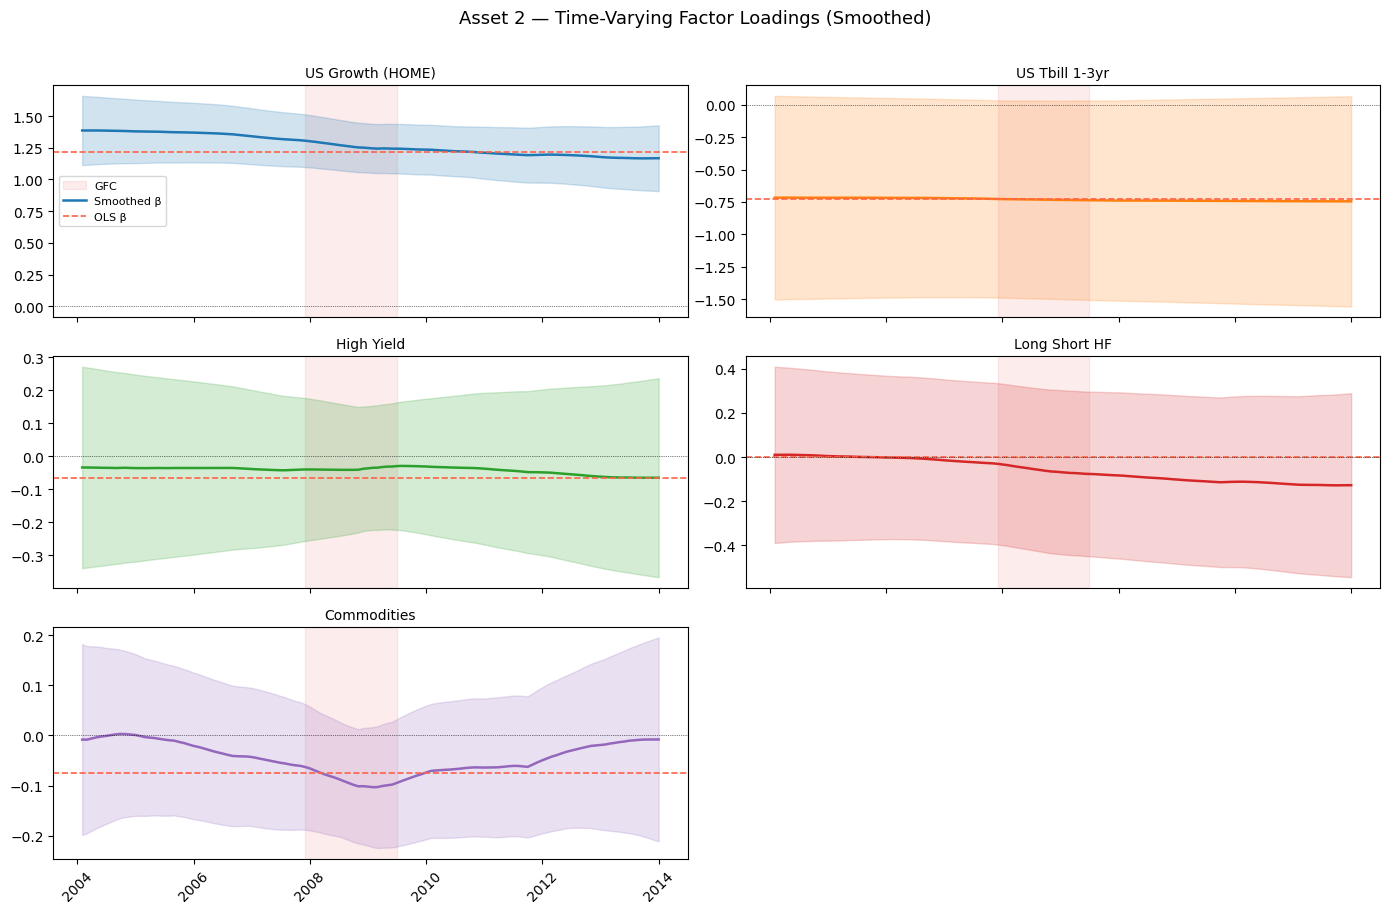

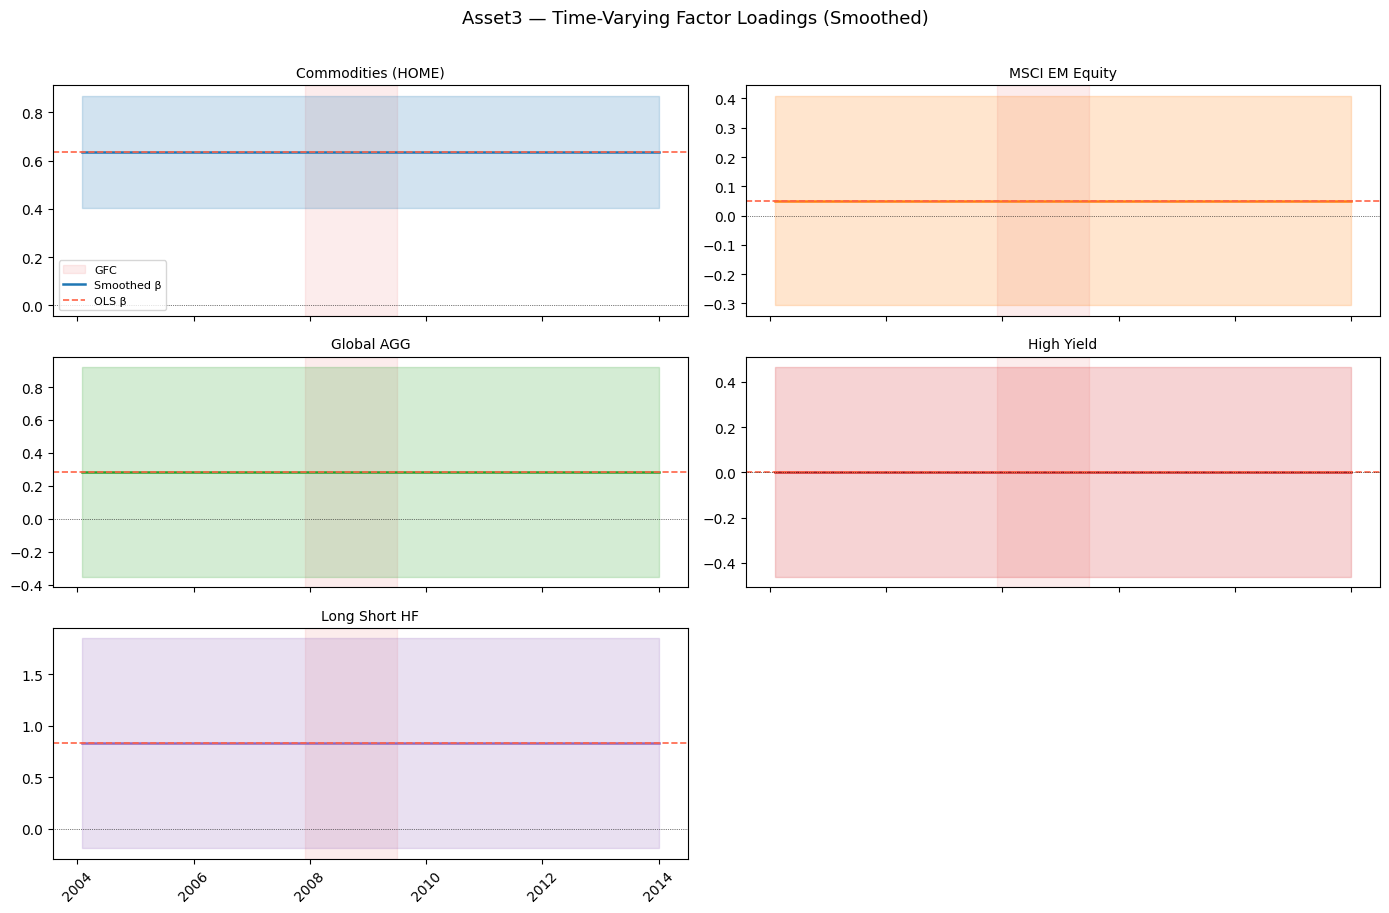

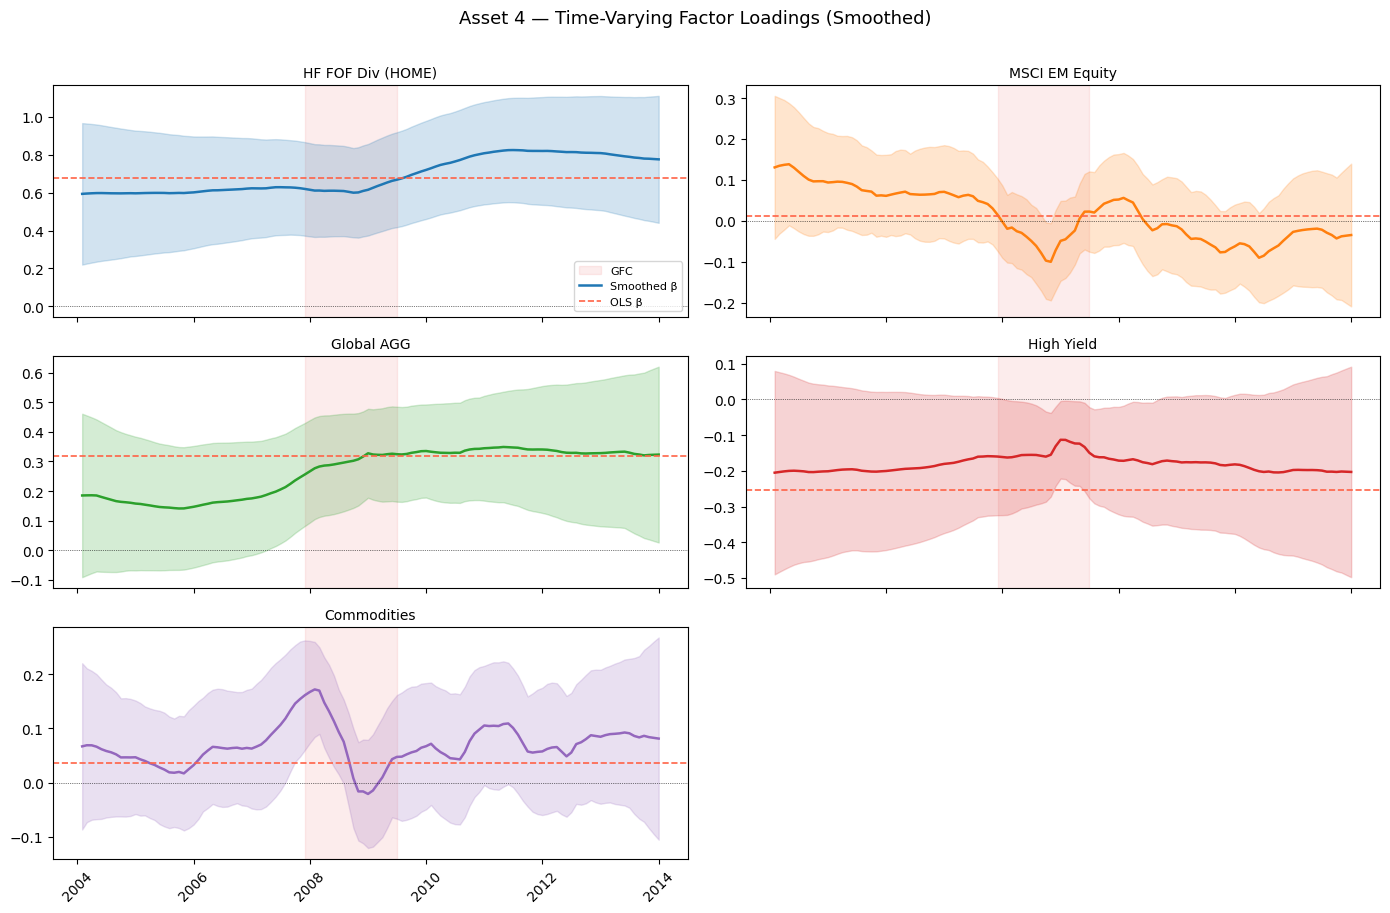

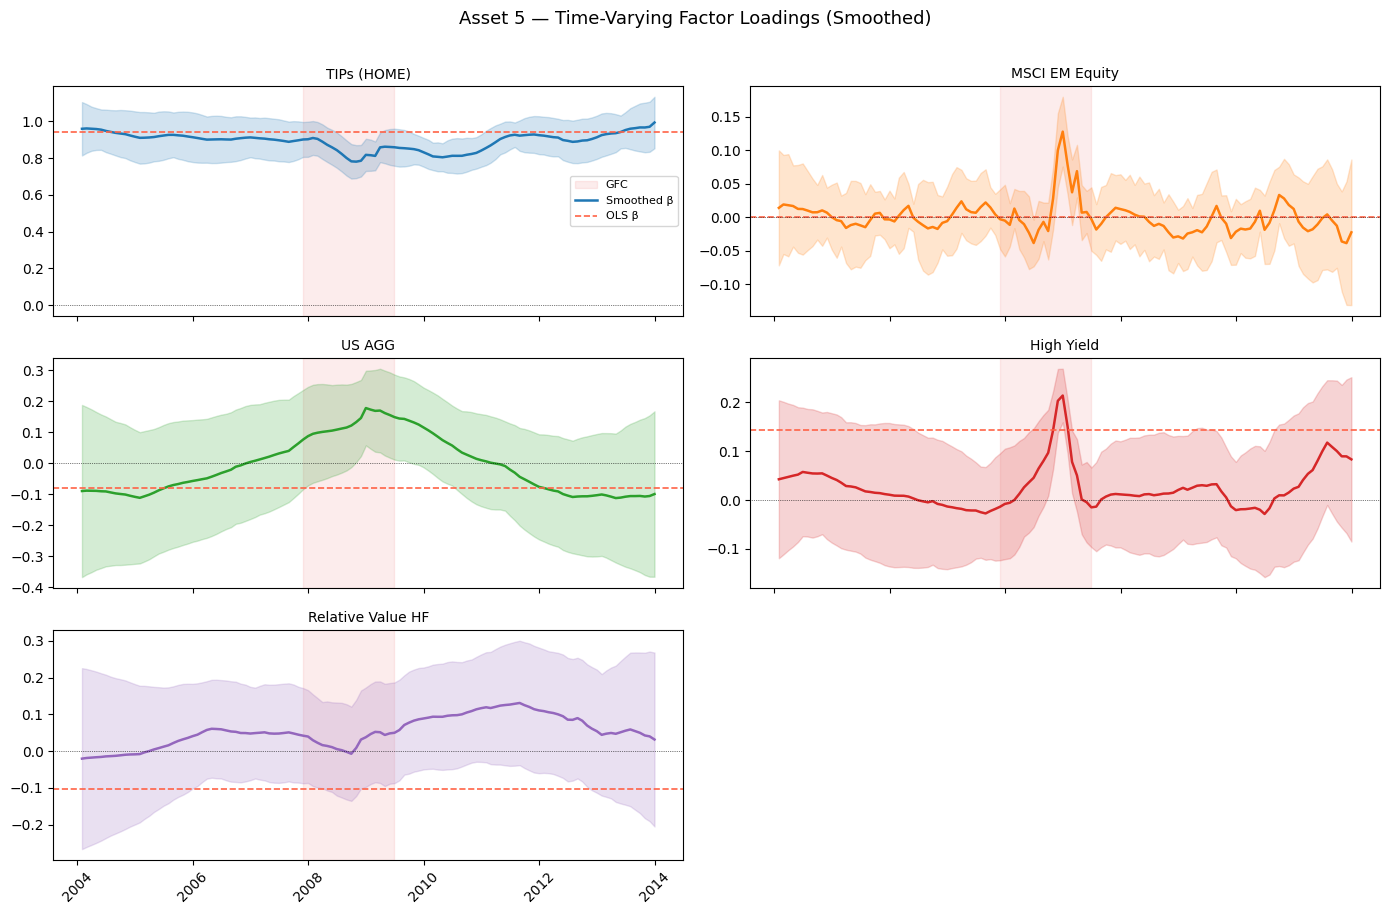

In [6]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

GFC_START = pd.Timestamp('2007-12-01')
GFC_END   = pd.Timestamp('2009-06-30')
PALETTE   = sns.color_palette('tab10', n_colors=5)

def plot_asset_grid(asset, model, factor_names, dates):
    K    = len(factor_names)
    cols = 2
    rows = (K + 1) // cols   # 3 rows for 5 factors (last row has 1 plot)

    F_mat    = F_all[factor_names].values
    beta_ols, *_ = np.linalg.lstsq(F_mat, r_all[asset].values, rcond=None)

    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3), sharex=True)
    axes = axes.flatten()
    fig.suptitle(f'{asset} — Time-Varying Factor Loadings (Smoothed)', fontsize=13, y=1.01)

    for k, (ax, fname) in enumerate(zip(axes, factor_names)):
        beta_path = model.beta_smoothed[:, k]
        std_path  = np.sqrt(model.P_smoothed[:, k, k])
        colour    = PALETTE[k]

        ax.axvspan(GFC_START, GFC_END, color='lightcoral', alpha=0.15, label='GFC')
        ax.fill_between(dates, beta_path - 2*std_path, beta_path + 2*std_path,
                        alpha=0.2, color=colour)
        ax.plot(dates, beta_path, color=colour, lw=1.8, label='Smoothed β')
        ax.axhline(beta_ols[k], color='tomato', lw=1.2, ls='--', label='OLS β')
        ax.axhline(0, color='black', lw=0.5, ls=':')

        role = ' (HOME)' if k == 0 else ''
        ax.set_title(f'{fname}{role}', fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.tick_params(axis='x', labelrotation=45)
        if k == 0:
            ax.legend(fontsize=8)

    for ax in axes[K:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{asset.replace(" ","_")}_v2_grid.png', dpi=150, bbox_inches='tight')
    plt.show()

for asset, model in models.items():
    plot_asset_grid(asset, model, ASSET_FACTORS[asset], dates)

---
## All-Factor Overlay + Long/Short Stacked Charts

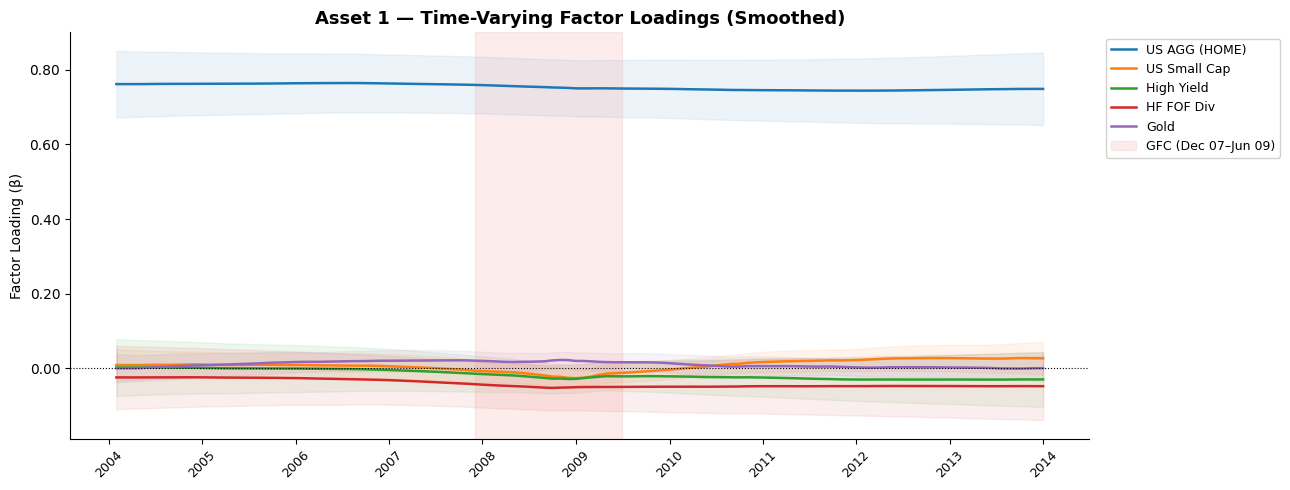

Saved: Asset_1_v2_overlay.png



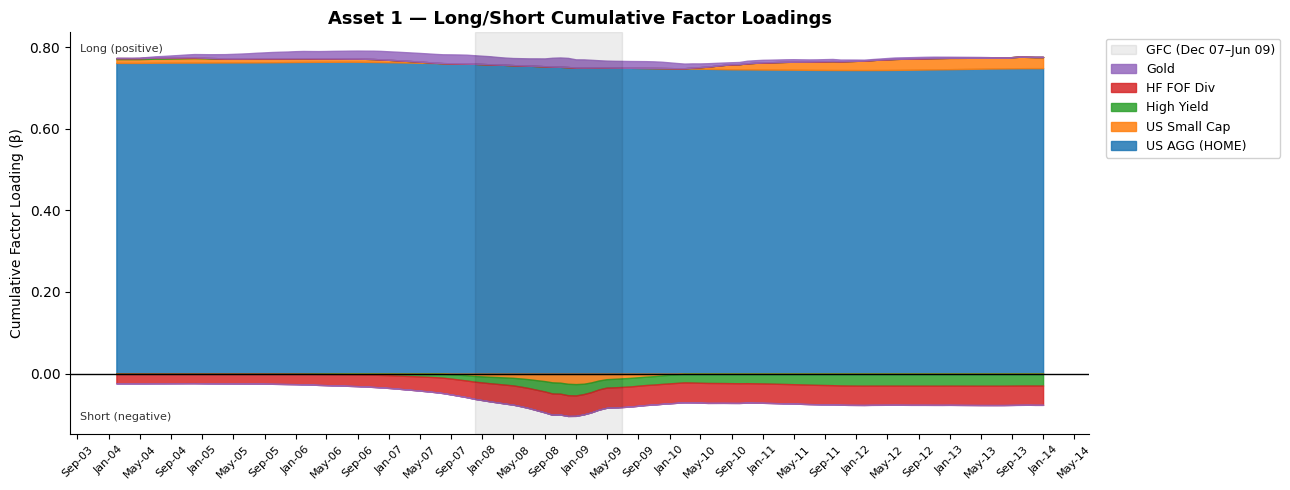

Saved: Asset_1_v2_longshort.png



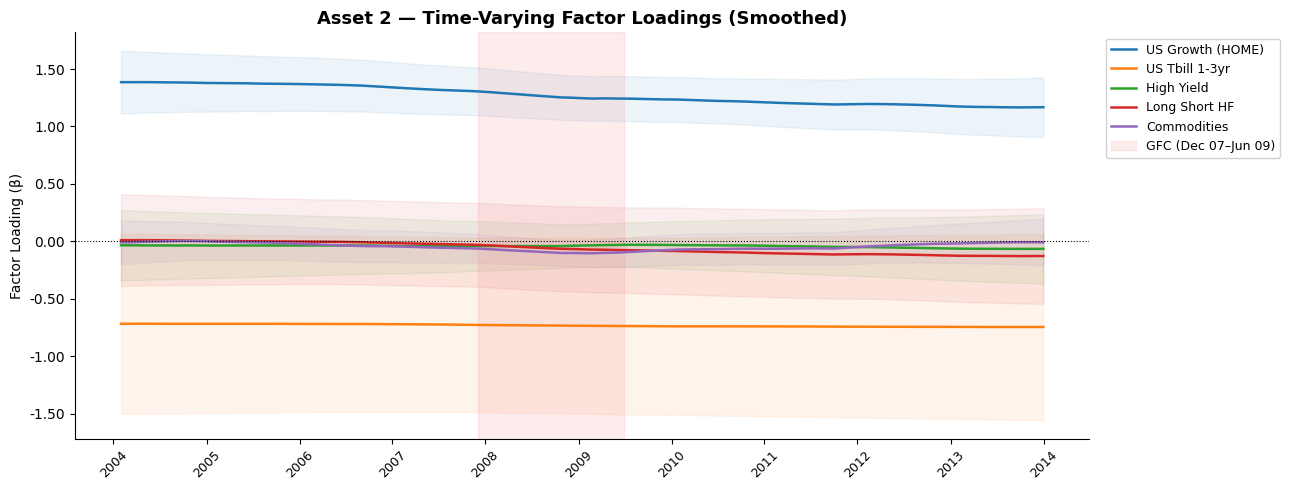

Saved: Asset_2_v2_overlay.png



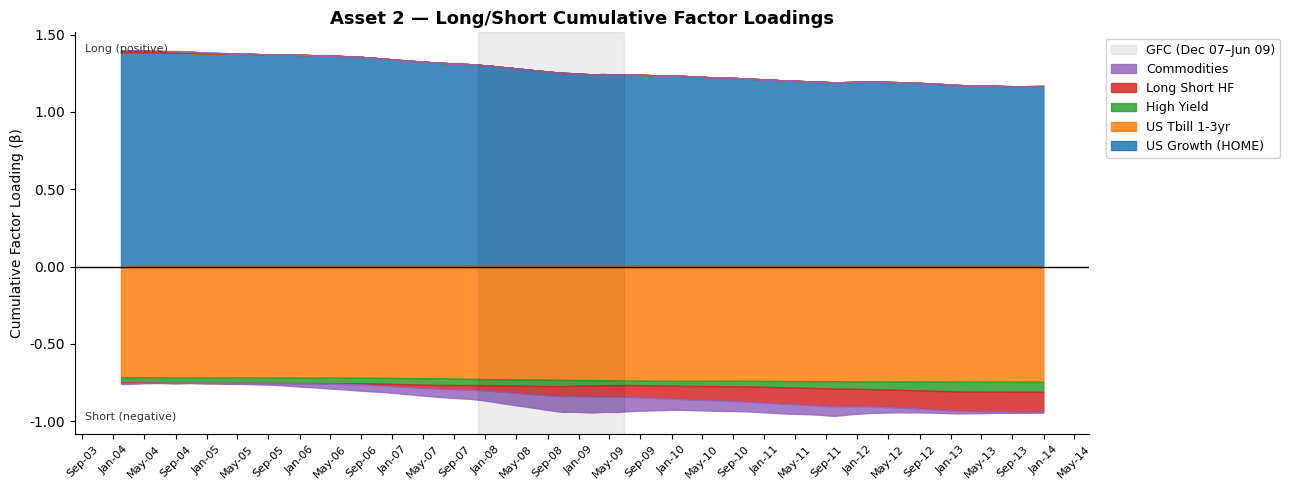

Saved: Asset_2_v2_longshort.png



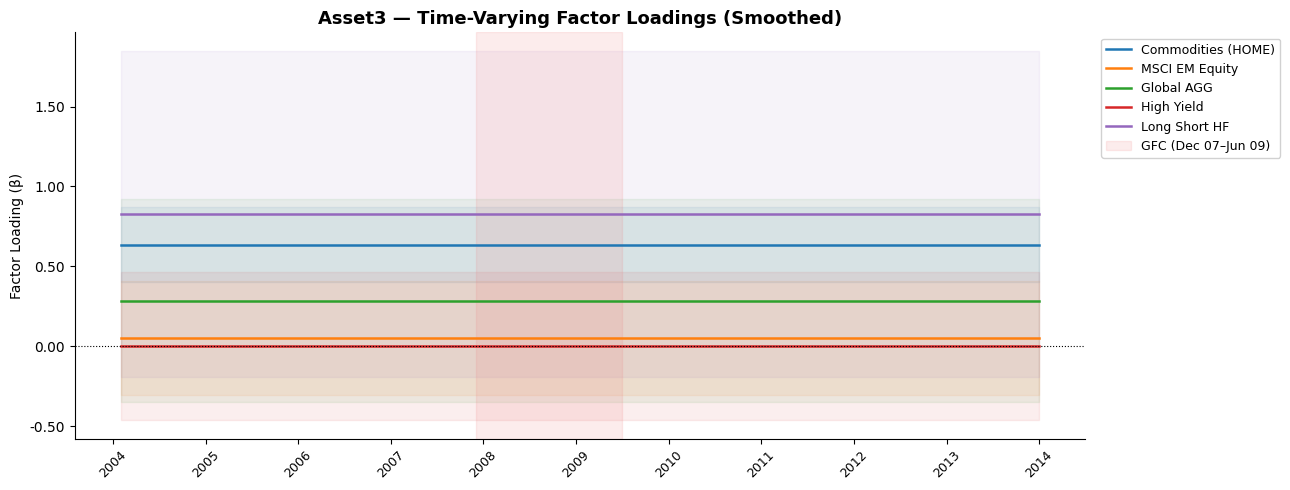

Saved: Asset3_v2_overlay.png



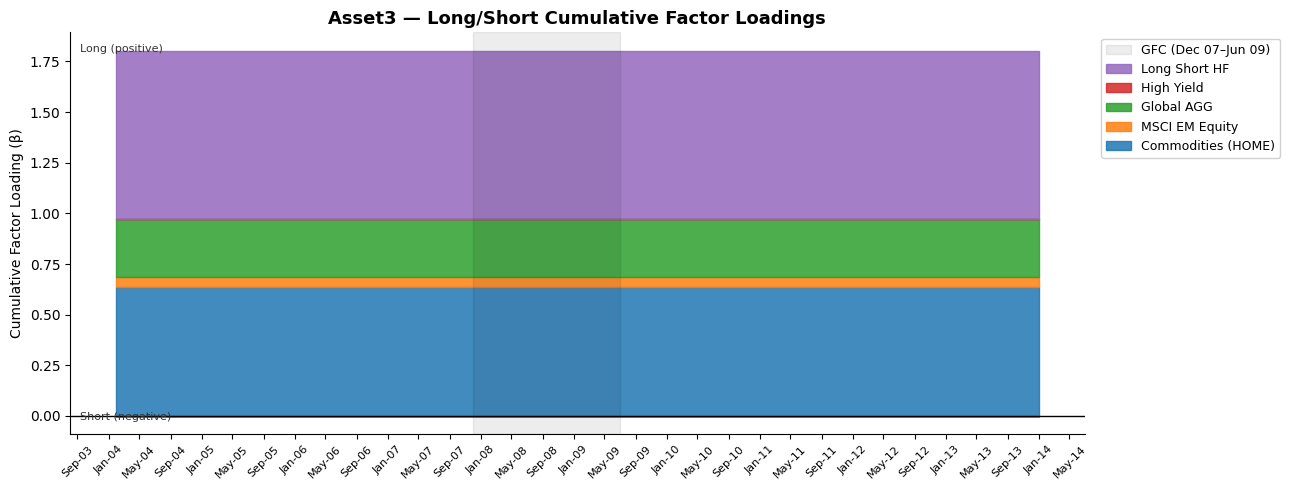

Saved: Asset3_v2_longshort.png



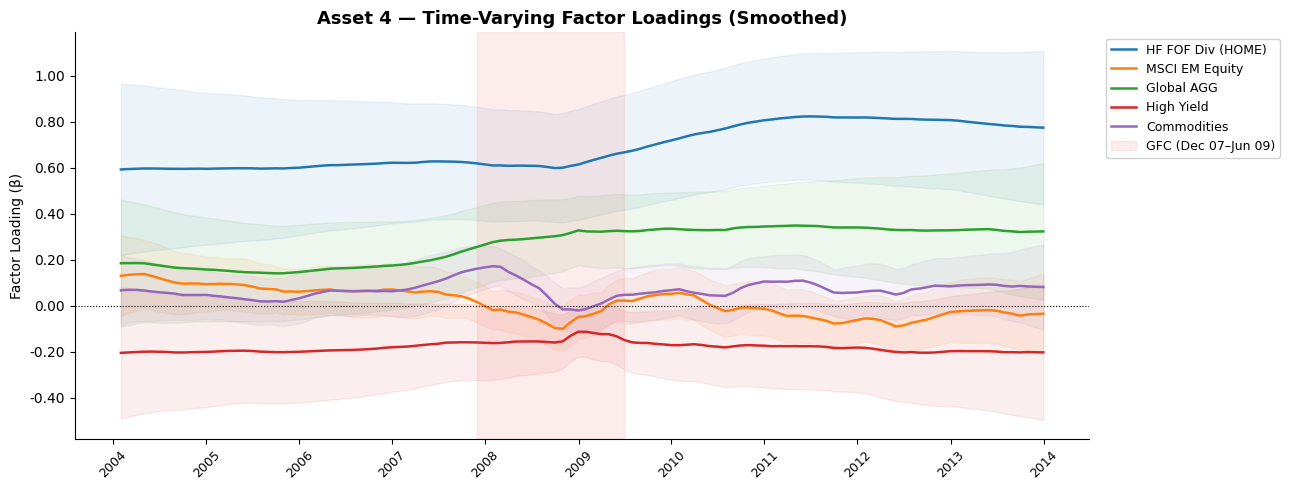

Saved: Asset_4_v2_overlay.png



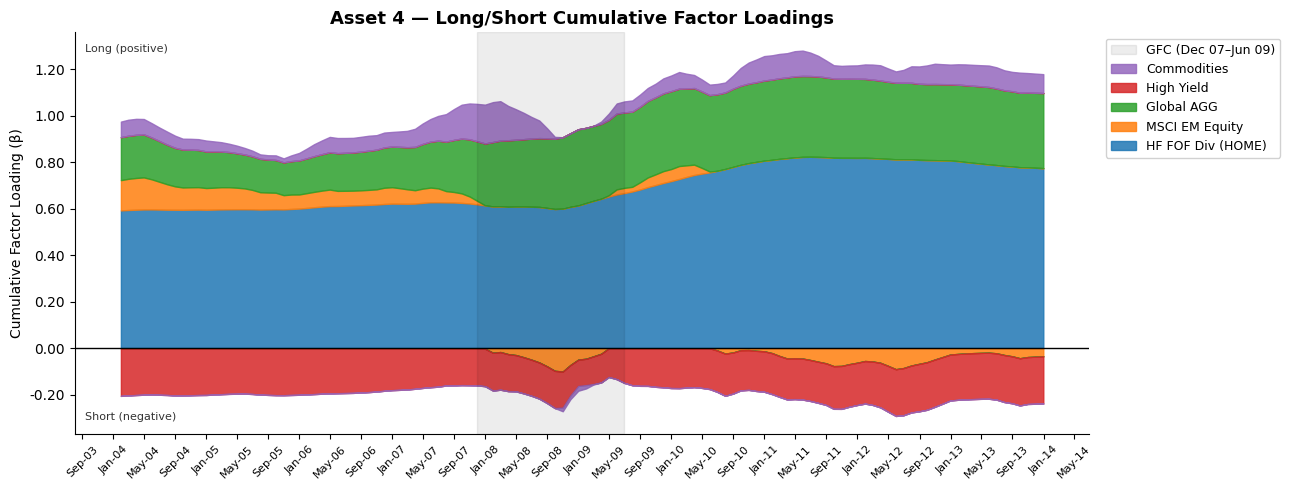

Saved: Asset_4_v2_longshort.png



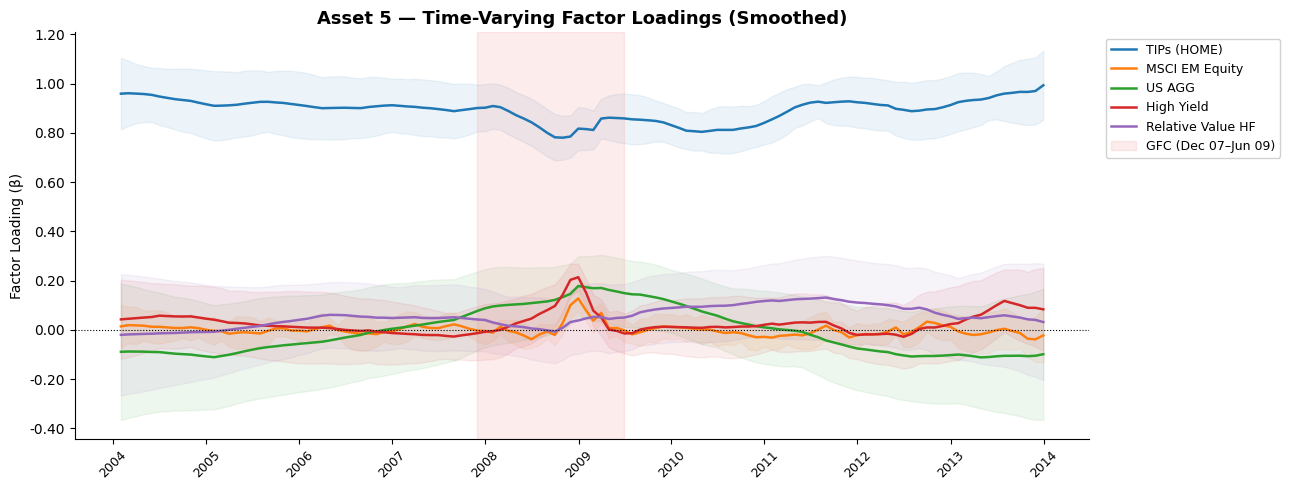

Saved: Asset_5_v2_overlay.png



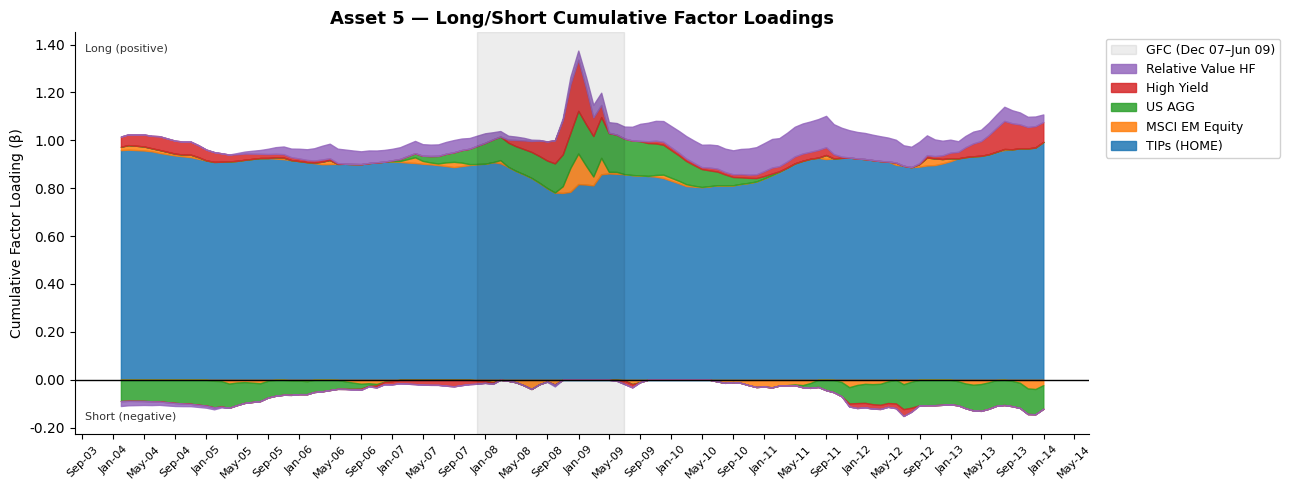

Saved: Asset_5_v2_longshort.png



In [7]:
def plot_all_loadings(asset, model, factor_names, dates):
    fig, ax = plt.subplots(figsize=(13, 5))
    F_mat    = F_all[factor_names].values
    beta_ols, *_ = np.linalg.lstsq(F_mat, r_all[asset].values, rcond=None)

    for k, fname in enumerate(factor_names):
        beta_path = model.beta_smoothed[:, k]
        std_path  = np.sqrt(model.P_smoothed[:, k, k])
        colour    = PALETTE[k]
        label     = f'{fname} (HOME)' if k == 0 else fname

        ax.fill_between(dates, beta_path - 2*std_path, beta_path + 2*std_path,
                        alpha=0.08, color=colour)
        ax.plot(dates, beta_path, color=colour, lw=1.8, label=label)

    ax.axhline(0, color='black', lw=0.8, ls=':')
    ax.axvspan(GFC_START, GFC_END, color='lightcoral', alpha=0.15, label='GFC (Dec 07–Jun 09)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.tick_params(axis='x', labelrotation=45, labelsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.set_title(f'{asset} — Time-Varying Factor Loadings (Smoothed)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Factor Loading (β)')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, framealpha=0.9)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(f'{asset.replace(" ","_")}_v2_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {asset.replace(" ","_")}_v2_overlay.png\n')


def plot_long_short_stacked(asset, model, factor_names, dates):
    betas = model.beta_smoothed
    K     = len(factor_names)
    pos   = np.where(betas > 0, betas, 0)
    neg   = np.where(betas < 0, betas, 0)

    fig, ax = plt.subplots(figsize=(13, 5))

    pos_bottom = np.zeros(len(dates))
    for k in range(K):
        label = f'{factor_names[k]} (HOME)' if k == 0 else factor_names[k]
        ax.fill_between(dates, pos_bottom, pos_bottom + pos[:, k],
                        color=PALETTE[k], alpha=0.85, label=label)
        pos_bottom += pos[:, k]

    neg_bottom = np.zeros(len(dates))
    for k in range(K):
        ax.fill_between(dates, neg_bottom + neg[:, k], neg_bottom,
                        color=PALETTE[k], alpha=0.85)
        neg_bottom += neg[:, k]

    ax.axhline(0, color='black', lw=1.0)
    ax.axvspan(GFC_START, GFC_END, color='black', alpha=0.07, zorder=5, label='GFC (Dec 07–Jun 09)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 5, 9]))
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.set_title(f'{asset} — Long/Short Cumulative Factor Loadings', fontsize=13, fontweight='bold')
    ax.set_ylabel('Cumulative Factor Loading (β)')
    ax.text(0.01, 0.97, 'Long (positive)', transform=ax.transAxes, fontsize=8, va='top', color='#333')
    ax.text(0.01, 0.03, 'Short (negative)', transform=ax.transAxes, fontsize=8, va='bottom', color='#333')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], loc='upper left', bbox_to_anchor=(1.01, 1),
              fontsize=9, framealpha=0.9)
    sns.despine(ax=ax)
    plt.tight_layout()
    fname = f'{asset.replace(" ","_")}_v2_longshort.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}\n')


for asset, model in models.items():
    plot_all_loadings(asset, model, ASSET_FACTORS[asset], dates)
    plot_long_short_stacked(asset, model, ASSET_FACTORS[asset], dates)

---
# Diagnostics

1. **Parameter table** — `sigma2`, `q`, signal-to-noise ratio, LL vs OLS
2. **Innovation diagnostics** — standardised innovations should be ≈ N(0,1) and serially uncorrelated (Ljung-Box p > 0.05)

=== Parameter Summary ===


,Home Factor,sigma2,q,q/sigma2,LL (Kalman),LL (OLS),LL gain,Converged
Asset,,,,,,,,
Asset 1,US AGG,0.000009,2.74e-05,2.9850,602.0,523.4,78.6,True
Asset 2,US Growth,0.000319,3.30e-04,1.0326,404.7,310.5,94.1,True
Asset3,Commodities,0.002316,7.28e-11,0.0000,292.4,196.3,96.0,True
Asset 4,HF FOF Div,0.000045,8.66e-04,19.4026,493.1,394.9,98.2,True
Asset 5,TIPs,0.000001,8.96e-04,681.5815,617.6,500.5,117.1,True



=== Innovation Diagnostics ===


,Mean (≈0),Std (≈1),Skew,LB p-val (lag10),White noise?
Asset,,,,,
Asset 1,0.2185,0.9543,0.394,0.217,YES
Asset 2,-0.0454,0.9780,0.301,0.847,YES
Asset3,-0.0355,0.9785,0.316,0.279,YES
Asset 4,0.0719,0.9764,0.157,0.524,YES
Asset 5,0.0381,0.9782,-0.412,0.037,NO


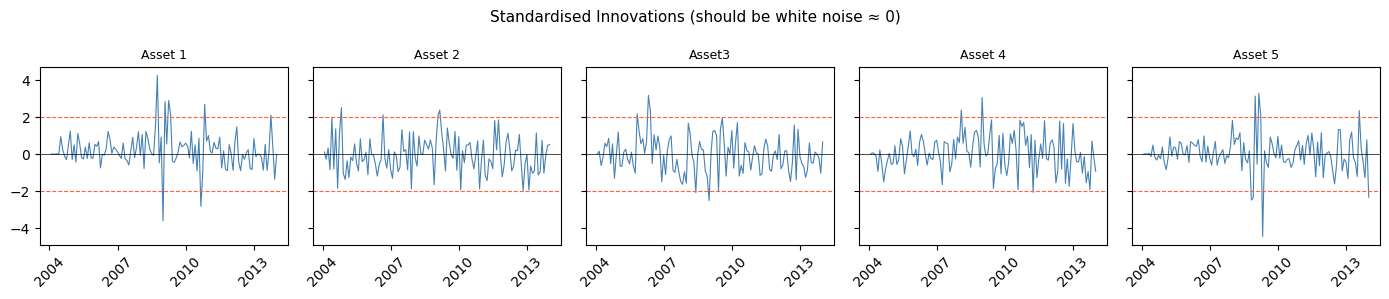

In [8]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# --- 1. Parameter summary ---
param_rows = []
for asset, m in models.items():
    factors  = ASSET_FACTORS[asset]
    F_mat    = F_all[factors].values
    beta_ols, *_ = np.linalg.lstsq(F_mat, r_all[asset].values, rcond=None)
    resid_ols    = r_all[asset].values - F_mat @ beta_ols
    ll_ols       = -0.5 * len(resid_ols) * (1 + np.log(2 * np.pi * np.var(resid_ols)))

    param_rows.append({
        'Asset'       : asset,
        'Home Factor' : factors[0],
        'sigma2'      : round(m.sigma2, 6),
        'q'           : f'{m.q:.2e}',
        'q/sigma2'    : f'{m.q / m.sigma2:.4f}',
        'LL (Kalman)' : round(m.log_likelihood(), 1),
        'LL (OLS)'    : round(ll_ols, 1),
        'LL gain'     : round(m.log_likelihood() - ll_ols, 1),
        'Converged'   : m._opt_result.success,
    })

df_params = pd.DataFrame(param_rows).set_index('Asset')
print('=== Parameter Summary ===')
display(df_params)

# --- 2. Innovation diagnostics ---
print('\n=== Innovation Diagnostics ===')
diag_rows = []
for asset, m in models.items():
    std_innov = m._innovations / np.sqrt(m._innov_vars)
    lb        = acorr_ljungbox(std_innov, lags=[10], return_df=True)
    diag_rows.append({
        'Asset'           : asset,
        'Mean (≈0)'       : round(std_innov.mean(), 4),
        'Std  (≈1)'       : round(std_innov.std(),  4),
        'Skew'            : round(pd.Series(std_innov).skew(), 3),
        'LB p-val (lag10)': round(lb['lb_pvalue'].values[0], 3),
        'White noise?'    : 'YES' if lb['lb_pvalue'].values[0] > 0.05 else 'NO',
    })

display(pd.DataFrame(diag_rows).set_index('Asset'))

# --- 3. Standardised innovation plot ---
fig, axes = plt.subplots(1, len(models), figsize=(14, 3), sharey=True)
fig.suptitle('Standardised Innovations (should be white noise ≈ 0)', fontsize=11)
for ax, (asset, m) in zip(axes, models.items()):
    std_innov = m._innovations / np.sqrt(m._innov_vars)
    ax.plot(dates, std_innov, lw=0.8, color='steelblue')
    ax.axhline( 2, color='tomato', lw=0.8, ls='--')
    ax.axhline(-2, color='tomato', lw=0.8, ls='--')
    ax.axhline( 0, color='black',  lw=0.5)
    ax.set_title(asset, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.tick_params(axis='x', labelrotation=45)
plt.tight_layout()
plt.show()

---
# Export Factor Loadings

Two CSVs — smoothed (full-sample) and filtered (real-time).  
Columns: MultiIndex `(Asset, Factor)`. Rows: monthly dates.

In [9]:
def loadings_to_df(models, asset_factors, dates, which='smoothed'):
    frames = {}
    for asset, m in models.items():
        betas = m.beta_smoothed if which == 'smoothed' else m.beta_filtered
        frames[asset] = pd.DataFrame(betas, index=dates, columns=asset_factors[asset])
    df_out = pd.concat(frames, axis=1)
    df_out.index.name = 'Date'
    return df_out

df_smoothed = loadings_to_df(models, ASSET_FACTORS, dates, which='smoothed')
df_filtered = loadings_to_df(models, ASSET_FACTORS, dates, which='filtered')

df_smoothed.to_csv('factor_loadings_v2_smoothed.csv')
df_filtered.to_csv('factor_loadings_v2_filtered.csv')

print('Saved: factor_loadings_v2_smoothed.csv')
print('Saved: factor_loadings_v2_filtered.csv')
print(f'Shape: {df_smoothed.shape}  ({df_smoothed.shape[0]} dates × {df_smoothed.shape[1]} columns)')
display(df_smoothed.head())

Saved: factor_loadings_v2_smoothed.csv
Saved: factor_loadings_v2_filtered.csv
Shape: (120, 25)  (120 dates × 25 columns)


Asset 1                                                Asset 2  \
              US AGG US Small Cap High Yield HF FOF Div      Gold US Growth   
Date                                                                          
2004-01-31  0.761319     0.009262   0.002532  -0.023872  0.000696  1.386012   
2004-02-29  0.761315     0.009242   0.002525  -0.023879  0.000710  1.385838   
2004-03-31  0.761300     0.009212   0.002518  -0.023898  0.000742  1.385911   
2004-04-30  0.761315     0.009220   0.002540  -0.023900  0.001085  1.386018   
2004-05-31  0.761517     0.009595   0.002608  -0.023850  0.002099  1.385670   

                                                                ...  \
           US Tbill 1-3yr High Yield Long Short HF Commodities  ...   
Date                                                            ...   
2004-01-31      -0.716965  -0.034091      0.010522   -0.008180  ...   
2004-02-29      -0.716983  -0.034232      0.010350   -0.008337  ...   
2004-03-31      -0.716808  -0.034416      0.010607   -0.005988  ...   
2004-04-30      -0.716639  -0.034612      0.010858   -0.003695  ...   
2004-05-31      -0.716865  -0.035067      0.010294   -0.002095  ...   

              Asset 4                                                   \
           HF FOF Div MSCI EM Equity Global AGG High Yield Commodities   
Date                                                                     
2004-01-31   0.593177       0.130359   0.184983  -0.205250    0.066982   
2004-02-29   0.594889       0.134267   0.185385  -0.203436    0.069006   
2004-03-31   0.596245       0.136673   0.185616  -0.201587    0.068906   
2004-04-30   0.597257       0.138101   0.184980  -0.200261    0.066391   
2004-05-31   0.597412       0.129638   0.179923  -0.199733    0.061738   

             Asset 5                                                        
                TIPs MSCI EM Equity    US AGG High Yield Relative Value HF  
Date                                                                        
2004-01-31  0.959138       0.013970 -0.089240   0.042528         -0.020405  
2004-02-29  0.960926       0.019040 -0.088079   0.044872         -0.018641  
2004-03-31  0.959362       0.017907 -0.088378   0.047364         -0.017619  
2004-04-30  0.957745       0.016736 -0.088700   0.049836         -0.016611  
2004-05-31  0.954348       0.012429 -0.090017   0.052055         -0.015798  

[5 rows x 25 columns]